In [ ]:
#LSTM model

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler


In [ ]:
device = torch.device('cpu')

In [ ]:
ticker = 'AAPL'
df= yf.download(ticker, '2020-01-01')

/tmp/ipython-input-255586931.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df= yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.538521,72.598899,71.292311,71.545897,135480400
2020-01-03,71.833313,72.594079,71.608707,71.765690,146322800
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200
2020-01-07,72.065147,72.671341,71.845369,72.415337,108872000
2020-01-08,73.224419,73.526310,71.768094,71.768094,132079200
...,...,...,...,...,...
2025-09-22,256.079987,256.640015,248.119995,248.300003,105517400
2025-09-23,254.429993,257.339996,253.580002,255.880005,60275200


<Axes: xlabel='Date'>

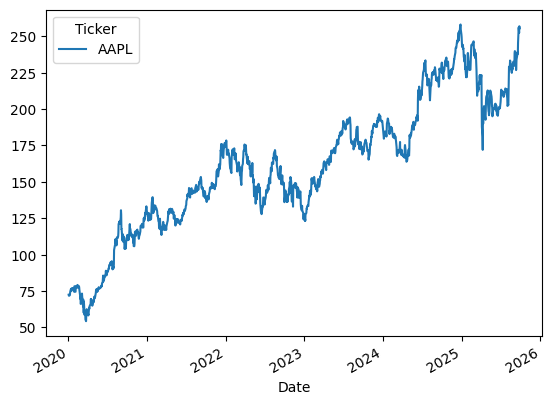

In [ ]:
df.Close.plot()

In [ ]:
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [ ]:
df.Close

Ticker,AAPL
Date,
2020-01-02,0.089415
2020-01-03,0.085954
2020-01-06,0.088763
2020-01-07,0.087092
2020-01-08,0.092781
...,...
2025-09-22,0.990069
2025-09-23,0.981973
2025-09-24,0.971570


In [ ]:
seq_lenght = 30
data = []

for i in range(len(df) - seq_lenght):
  data.append(df.Close[i:i+seq_lenght])

data = np.array(data)

In [ ]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [ ]:
class PredictionModel(nn.Module):

  def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
    super(PredictionModel, self).__init__()
    self.num_layers = num_layers
    self.hidden_dim = hidden_dim

    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

    out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
    out = self.fc(out[:, -1, :])

    return out

In [ ]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
num_epochs = 200
losses = []


for i in range(num_epochs):
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)

    losses.append(loss.item())  # sauvegarde de la loss

    if i % 25 == 0:
        print(f"Epoch {i}, Loss: {loss.item():.5f}")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 0, Loss: 0.09225
Epoch 25, Loss: 0.02435
Epoch 50, Loss: 0.00217
Epoch 75, Loss: 0.00073
Epoch 100, Loss: 0.00055
Epoch 125, Loss: 0.00050
Epoch 150, Loss: 0.00046
Epoch 175, Loss: 0.00043


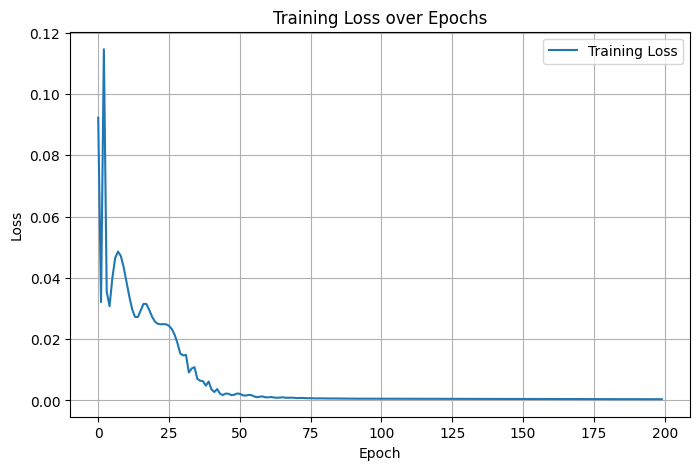

In [ ]:
plt.figure(figsize=(8,5))
# si tu as une variable 'loss' tensor
plt.plot([l.detach().numpy() if isinstance(l, torch.Tensor) else l for l in losses], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.eval()

y_test_pred = model(X_test)

y_train_pred= scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred= scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test= scaler.inverse_transform(y_test.detach().cpu().numpy())

In [ ]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [ ]:
train_rmse

4.073762893676758

In [ ]:
test_rmse

6.720766067504883

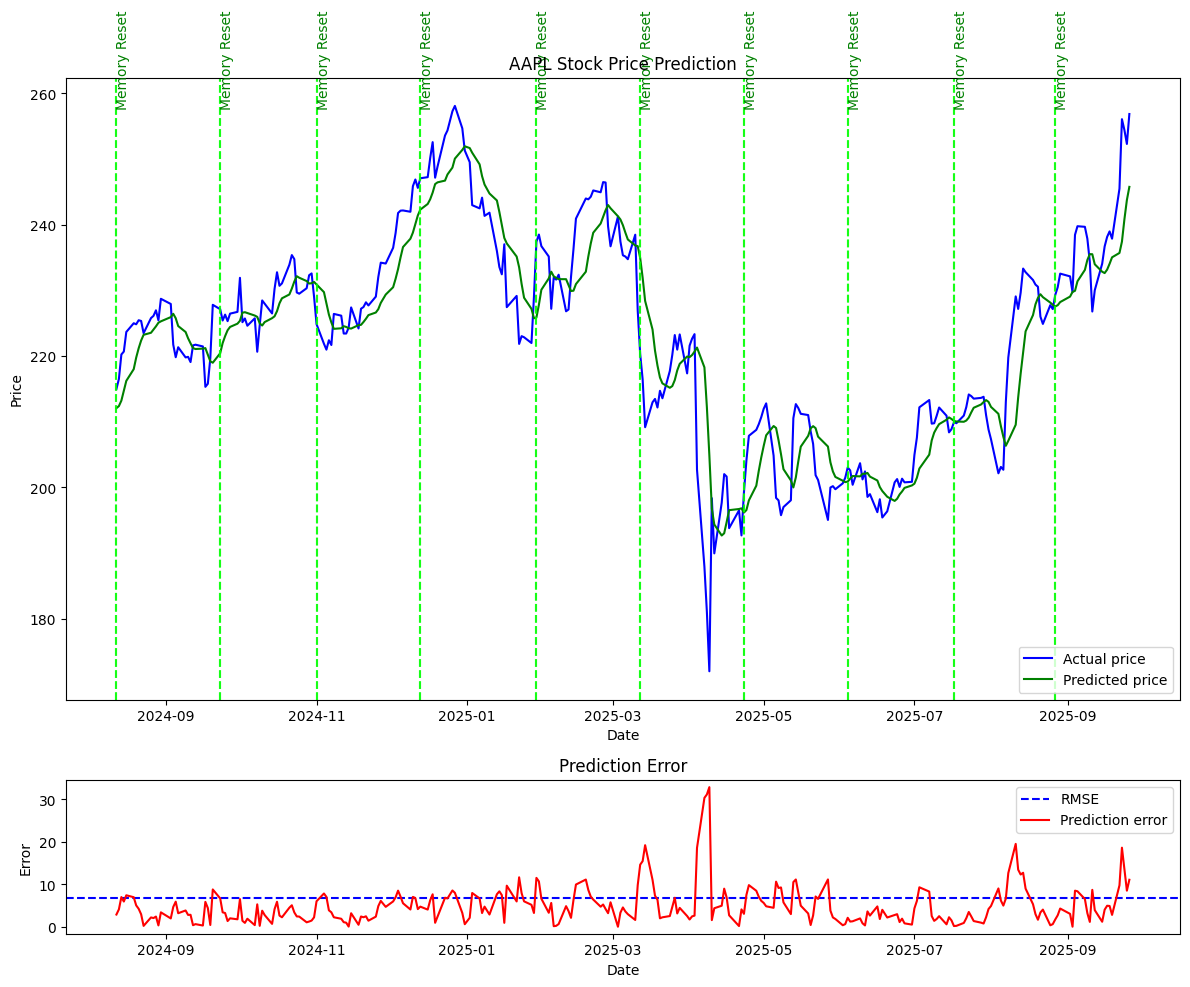

In [ ]:
fig = plt.figure(figsize=(12,10))

gs = fig.add_gridspec(4, 1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted price')

# Ajouter des traits verticaux tous les 29 jours
for i in range(0, len(y_test), 29):
    ax1.axvline(df.iloc[-len(y_test):].index[i], color='lime', linestyle='--', alpha=0.7)

ax1.legend()
ax1.set_title(f"{ticker} Stock Price Prediction")
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction error')

# Même traits verticaux dans le subplot erreur
for i in range(0, len(y_test), 29):
    ax1.axvline(df.iloc[-len(y_test):].index[i], color='lime', linestyle='--', alpha=0.7)
    ax1.text(df.iloc[-len(y_test):].index[i], max(y_test), 'Memory Reset', rotation=90, color='green')


ax2.legend()
ax2.set_title('Prediction Error')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')

plt.tight_layout()
plt.show()


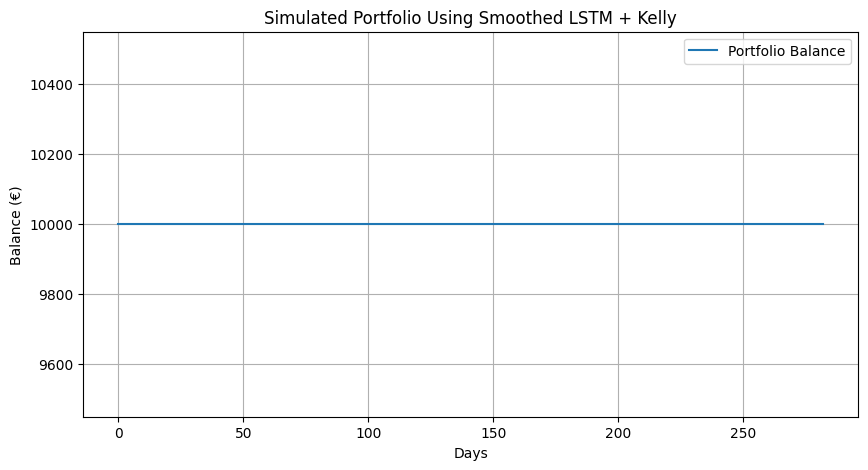

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Paramètres ---
initial_balance = 10000
max_fraction = 0.1    # fraction max du capital par trade
stop_loss = 0.02      # perte max 2% par trade
take_profit = 0.03    # gain max 3% par trade
threshold = 0.001     # delta minimum pour trader

# --- Signal lissé ---
y_pred_smooth = pd.Series(y_test_pred.flatten()).ewm(span=3).mean().values
signal = np.where((y_pred_smooth - y_test.flatten()) > threshold, 1,
                  np.where((y_pred_smooth - y_test.flatten()) < -threshold, -1, 0))

# --- Aligner les longueurs pour daily returns ---
daily_returns = np.diff(y_test.flatten()) / y_test[:-1].flatten()
signal = signal[:-1]

# --- Estimation de probabilité de gain (simple) ---
p_est = np.mean(y_train_pred.flatten() > y_train.flatten())

# --- Backtest ---
balance = initial_balance
balances = [balance]
position = 0  # 1 = long, -1 = short, 0 = cash

for i in range(len(daily_returns)):
    # changer de position seulement si signal différent
    if signal[i] != 0 and signal[i] != position:
        position = signal[i]

    # fraction Kelly conservatrice
    b = 1  # odds 1:1 pour spot trading
    f = (p_est * b - (1 - p_est)) / b
    f = np.clip(f, 0, max_fraction)

    # calcul PnL
    pnl = f * daily_returns[i] * position

    # appliquer stop-loss / take-profit
    pnl = np.clip(pnl, -stop_loss, take_profit)

    # mise à jour du solde
    balance += balance * pnl
    balances.append(balance)

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(balances, label='Portfolio Balance')
plt.title('Simulated Portfolio Using Smoothed LSTM + Kelly')
plt.xlabel('Days')
plt.ylabel('Balance (€)')
plt.grid(True)
plt.legend()
plt.show()
